# Part I - Construction Spending Exploration

## Introduction
This notebook explores the **U.S. Construction Spending dataset** sourced from the U.S. Census Bureau, covering monthly construction spending from January 2002 to December 2016. The data captures spending across private and public sectors, broken down by construction type (office, commercial, manufacturing, lodging, healthcare, residential, and more).

The central question guiding this analysis is:
> *What does 14 years of U.S. construction spending reveal about how private investors allocate capital across sectors — and what do economic shocks teach us about developer priorities?*

By systematically exploring univariate, bivariate, and multivariate relationships, this analysis aims to mirror the kind of macro market intelligence that real estate developers and construction firms use when making investment decisions.

## Preliminary Wrangling

In [1]:
# Import all packages and set plots to be embedded inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

# Display settings for clean, readable plots
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sb.set_palette('muted')

# Display settings for dataframes
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print('All packages loaded successfully.')

All packages loaded successfully.


> Load in your dataset and describe its properties through the questions below. Try and motivate your exploration goals through this section.


In [2]:
# Load the dataset from the data subfolder
df = pd.read_csv('data/construction_spending.csv')

# Preview shape and first few rows
print(f'Dataset shape: {df.shape}')
print(f'Date range: {df["time.year"].min()} - {df["time.year"].max()}')
print(f'Columns: {df.shape[1]}')
df.head()

Dataset shape: (169, 119)
Date range: 2002 - 2016
Columns: 119


,time.index,time.month,time.month name,time.period,time.year,annual.combined.amusement and recreation,annual.combined.commercial,annual.combined.communication,annual.combined.conservation and development,annual.combined.educational,annual.combined.health care,annual.combined.highway and street,annual.combined.lodging,annual.combined.manufacturing,annual.combined.nonresidential,annual.combined.office,annual.combined.power,annual.combined.public safety,annual.combined.religious,annual.combined.residential,annual.combined.sewage and waste disposal,annual.combined.total construction,annual.combined.transportation,annual.combined.water supply,annual.private.amusement and recreation,...,current.private.religious,current.private.residential,current.private.sewage and waste disposal,current.private.total construction,current.private.transportation,current.private.water supply,current.public.amusement and recreation,current.public.commercial,current.public.communication,current.public.conservation and development,current.public.educational,current.public.health care,current.public.highway and street,current.public.lodging,current.public.manufacturing,current.public.nonresidential,current.public.office,current.public.power,current.public.public safety,current.public.religious,current.public.residential,current.public.sewage and waste disposal,current.public.total construction,current.public.transportation,current.public.water supply
0,1,1,Jan,Jan2002,2002,17866,68254,18873,3603,72357,25746,62723,11862,28318,475704,49140,46050,8468,8745,382979,16392,858654,25547,11760,7822,...,667,25572,0,45273,444,0,719,299,0,268,4126,384,3168,0,0,13844,697,273,637,0,400,1127,14243,1285,826
1,2,2,Feb,Feb2002,2002,18317,65840,19943,3712,74336,25438,61801,11058,25977,470946,47728,44674,8818,8520,391434,17059,862338,25662,12063,7925,...,637,25298,0,44475,412,0,755,268,0,277,4157,353,2969,0,0,13691,661,284,640,0,423,1119,14113,1318,851
2,3,3,Mar,Mar2002,2002,17988,66722,19092,3332,72247,25639,53009,11036,24998,453504,46215,41738,8035,8472,390942,16286,844551,26742,11954,7472,...,656,29407,0,49396,497,0,816,248,0,257,4205,371,2959,0,0,13967,728,222,626,0,420,1182,14386,1452,865
3,4,4,Apr,Apr2002,2002,17264,64879,19150,3076,74553,26117,53053,12104,24482,453776,46709,41380,8025,8795,404255,16366,858240,25609,12213,7636,...,710,32578,0,53283,570,0,824,291,0,244,4697,387,3766,0,0,15791,798,369,638,0,430,1272,16221,1479,967
4,5,5,May,May2002,2002,16988,62741,18735,3199,75577,26459,56278,11838,23862,451789,45636,37871,8023,8510,399164,16237,850935,26452,13384,7551,...,697,34621,0,55009,626,0,832,289,0,256,5095,370,4985,0,0,17937,864,388,654,0,438,1417,18375,1652,1082


In [3]:
# Inspect data types, null values, and key column groups
print('=== DATA TYPES (first 10 columns) ===')
print(df.dtypes[:10])

print('\n=== NULL VALUES (any column with nulls) ===')
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls[nulls > 0].any() else 'No null values found.')

print('\n=== KEY PRIVATE SECTOR COLUMNS ===')
private_cols = [c for c in df.columns if 'annual.private.' in c]
print(private_cols)

print('\n=== BASIC STATS FOR KEY PRIVATE SECTORS ===')
focus = ['annual.private.office', 'annual.private.commercial',
         'annual.private.manufacturing', 'annual.private.lodging',
         'annual.private.health care', 'annual.private.residential',
         'annual.private.total construction']
print(df[focus].describe())

=== DATA TYPES (first 10 columns) ===
time.index                                      int64
time.month                                      int64
time.month name                                   str
time.period                                       str
time.year                                       int64
annual.combined.amusement and recreation        int64
annual.combined.commercial                      int64
annual.combined.communication                   int64
annual.combined.conservation and development    int64
annual.combined.educational                     int64
dtype: object

=== NULL VALUES (any column with nulls) ===
No null values found.

=== KEY PRIVATE SECTOR COLUMNS ===
['annual.private.amusement and recreation', 'annual.private.commercial', 'annual.private.communication', 'annual.private.conservation and development', 'annual.private.educational', 'annual.private.health care', 'annual.private.highway and street', 'annual.private.lodging', 'annual.private.manufacturing'

### What is the structure of your dataset?

The dataset contains **169 rows and 119 columns**. Each row represents one month of construction activity, spanning from January 2002 to December 2016 (15 years of monthly data). Columns are organized into three groups:
- **Time variables**: index, month, month name, period string, and year
- **Spending variables**: broken into `annual.private`, `annual.public`, and `annual.combined` prefixes, each covering 17 construction sectors
- **Valuation types**: annual rate and current dollar estimates for each sector

All spending values are integers (millions of dollars). There are no null values in the dataset.

### What is/are the main feature(s) of interest in your dataset?

The main features of interest are the **private sector spending columns**, particularly:
- `annual.private.office` — office building investment
- `annual.private.commercial` — retail and commercial space
- `annual.private.manufacturing` — industrial/factory construction
- `annual.private.lodging` — hotel and hospitality development
- `annual.private.health care` — medical facility construction
- `annual.private.total construction` — aggregate private investment

These capture the capital allocation decisions of private developers and investors across sectors over time.

### What features in the dataset do you think will help support your investigation into your feature(s) of interest?

Several supporting features will enrich the analysis:
- **`time.year`** and **`time.month`** — enable trend analysis and seasonality exploration
- **`annual.public.total construction`** — serves as a comparison baseline to private investment, revealing how government spending compensates during private sector downturns
- **`annual.private.residential`** — provides contrast between residential and commercial developer behavior
- An **engineered `era` column** will be created to classify each month into four economic periods: Pre-Recession (2002–2007), Recession (2008–2009), Early Recovery (2010–2012), and Growth (2013–2016), enabling direct comparison of developer behavior across market conditions

In [4]:
# --- Feature Engineering ---
# Create an 'era' column to classify each month into four economic periods.
# This allows us to compare developer behavior across distinct market conditions.

def assign_era(year):
    """Classify a year into one of four economic eras."""
    if year <= 2007:
        return 'Pre-Recession (2002-2007)'
    elif year <= 2009:
        return 'Recession (2008-2009)'
    elif year <= 2012:
        return 'Early Recovery (2010-2012)'
    else:
        return 'Growth (2013-2016)'

df['era'] = df['time.year'].apply(assign_era)

# Define era order for use in ordered plots throughout the notebook
era_order = [
    'Pre-Recession (2002-2007)',
    'Recession (2008-2009)',
    'Early Recovery (2010-2012)',
    'Growth (2013-2016)'
]

# Verify the distribution
print('Months per era:')
print(df['era'].value_counts()[era_order])
print(f'\nEra column added successfully. Total rows: {len(df)}')

Months per era:
era
Pre-Recession (2002-2007)     72
Recession (2008-2009)         24
Early Recovery (2010-2012)    36
Growth (2013-2016)            37
Name: count, dtype: int64

Era column added successfully. Total rows: 169


C:\Users\jshol\AppData\Local\Temp\ipykernel_9604\1199752281.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['era'] = df['time.year'].apply(assign_era)


## Univariate Exploration

In this section, I examine the distributions of individual variables to understand 
the shape, spread, and central tendency of key construction spending columns before 
exploring relationships between variables.

**Assumptions going in:**
- Private sector spending likely follows a roughly normal distribution, but may show 
skewness due to the 2008 recession pulling values downward
- Residential spending likely dominates private totals given the housing market's size
- The dataset should be evenly distributed across years (12 months each)

**Questions this section will answer:**
1. How is private office spending distributed — is it symmetric or skewed by the recession?
2. How is total private construction spending distributed across all 169 months?
3. Is our dataset complete — do we have consistent monthly coverage across all 15 years?
4. Which private sectors receive the most investment on average?
5. How is private commercial spending distributed compared to office?

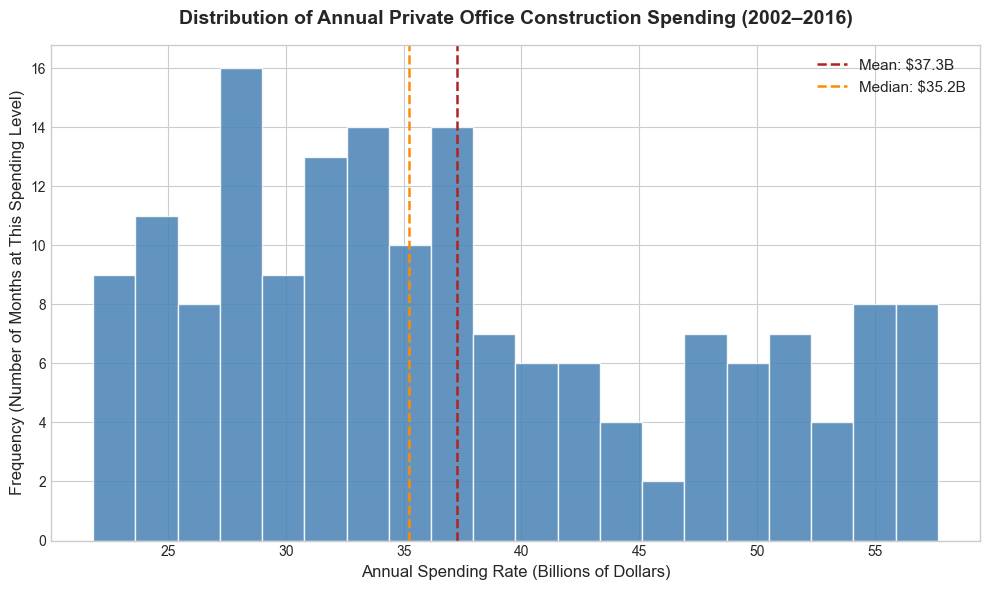

In [5]:
# --- Plot 01: Histogram — Distribution of Annual Private Office Spending ---
# Question: How is private office spending distributed across 2002–2016?
# Is it roughly normal or skewed by the recession?

# Convert to billions for readability
office_billions = df['annual.private.office'] / 1000

fig, ax = plt.subplots(figsize=(10, 6))

# Plot histogram
ax.hist(office_billions, bins=20, color='steelblue', edgecolor='white', alpha=0.85)

# Add mean and median reference lines
mean_val = office_billions.mean()
median_val = office_billions.median()
ax.axvline(mean_val, color='firebrick', linestyle='--', linewidth=1.8,
           label=f'Mean: ${mean_val:.1f}B')
ax.axvline(median_val, color='darkorange', linestyle='--', linewidth=1.8,
           label=f'Median: ${median_val:.1f}B')

# Labels and formatting
ax.set_title('Distribution of Annual Private Office Construction Spending (2002–2016)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Annual Spending Rate (Billions of Dollars)', fontsize=12)
ax.set_ylabel('Frequency (Number of Months at This Spending Level)', fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()



>**Rubric Tip**: Visualizations should depict the data appropriately so that the plots are easily interpretable. You should choose an appropriate plot type, data encodings, and formatting as needed. The formatting may include setting/adding the title, labels, legend, and comments. Also, do not overplot or incorrectly plot ordinal data.

### Plot 1 Observations — Private Office Spending Distribution

The distribution of monthly private office construction spending is **roughly bimodal**,
with one cluster around 27–32B and a second around 35–40B. This shape reflects two
distinct market regimes within the dataset:

- The lower cluster corresponds primarily to **recession and early recovery years**
(2009–2012) when office construction investment dropped sharply
- The upper cluster and right tail (45B–57B) represent **pre-recession boom years**
(2006–2008) and the **post-2013 growth period**
- The mean (37.3B) sits above the median (35.2B), indicating a slight **right skew**
pulled by the high-spending boom years
- No transformations were needed — the spread is reasonable and there are no extreme outliers

This distribution suggests that office spending does not follow a single normal pattern
but instead reflects the underlying economic cycle, which we will explore further in
the bivariate and multivariate sections.

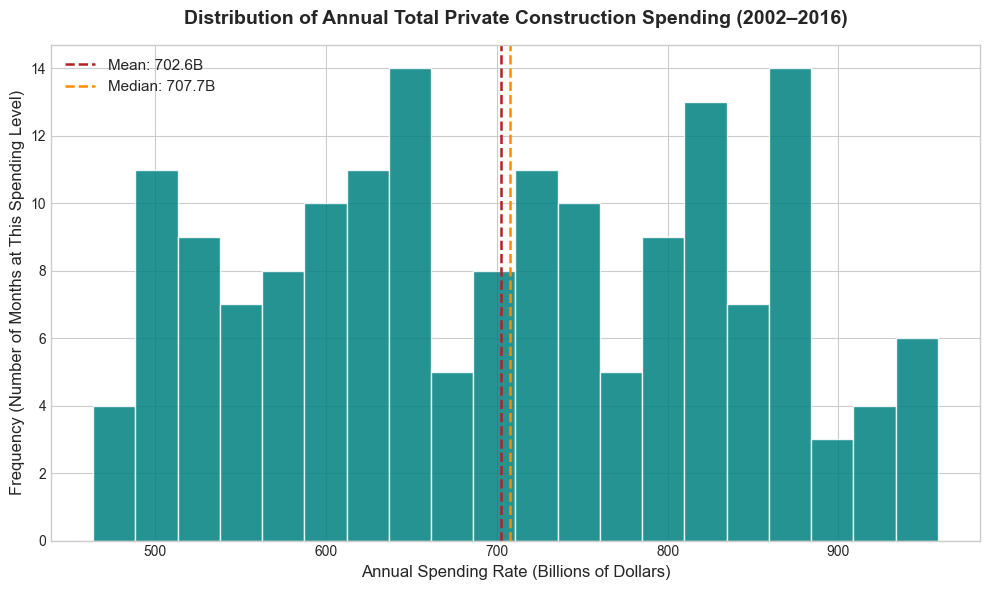

In [6]:
# --- Plot 02: Histogram — Distribution of Total Private Construction Spending ---
# Question: How is total private construction spending distributed across all 169 months?
# Does the recession create a bimodal or skewed shape?

# Convert to billions
total_billions = df['annual.private.total construction'] / 1000

fig, ax = plt.subplots(figsize=(10, 6))

# Plot histogram
ax.hist(total_billions, bins=20, color='teal', edgecolor='white', alpha=0.85)

# Add mean and median reference lines
mean_val = total_billions.mean()
median_val = total_billions.median()
ax.axvline(mean_val, color='firebrick', linestyle='--', linewidth=1.8,
           label=f'Mean: {mean_val:.1f}B')
ax.axvline(median_val, color='darkorange', linestyle='--', linewidth=1.8,
           label=f'Median: {median_val:.1f}B')

# Labels and formatting
ax.set_title('Distribution of Annual Total Private Construction Spending (2002–2016)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Annual Spending Rate (Billions of Dollars)', fontsize=12)
ax.set_ylabel('Frequency (Number of Months at This Spending Level)', fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

### Plot 2 Observations — Total Private Construction Spending Distribution

The distribution of total monthly private construction spending shows a **roughly 
bimodal shape**, with two distinct clusters visible:

- A lower cluster around **460–600B** representing the recession and early recovery 
period (2009–2012) when private investment contracted sharply across all sectors
- A higher cluster around **780–960B** representing the pre-recession boom (2002–2007) 
and the post-2013 growth period

Notably, the mean (702.6B) and median (707.7B) are nearly identical, suggesting 
the two clusters are roughly balanced in size — the dataset captures almost equal 
time in "high investment" and "low investment" regimes.

This wide spread (460B min to 958B max) confirms that economic cycles create 
dramatically different construction environments — a nearly **2x difference** between 
recession lows and boom highs. This sets up a key question for developers: which 
sectors drive that gap, and which remain stable regardless of conditions?

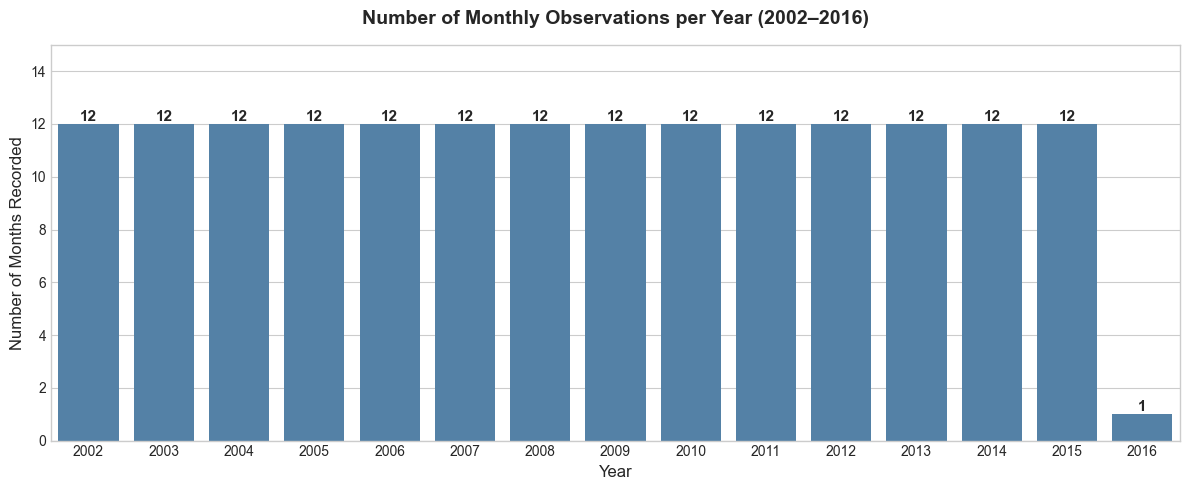

In [7]:
# --- Plot 03: Count Plot — Number of Months per Year ---
# Question: Is our dataset complete and evenly distributed across all 15 years?

fig, ax = plt.subplots(figsize=(12, 5))

# Count months per year
sb.countplot(data=df, x='time.year', color='steelblue', ax=ax)

# Add count labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Labels and formatting
ax.set_title('Number of Monthly Observations per Year (2002–2016)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Months Recorded', fontsize=12)
ax.set_ylim(0, 15)

plt.tight_layout()
plt.show()

### Plot 3 Observations — Monthly Data Completeness by Year

The dataset is **complete for 2002–2015**, with exactly 12 months recorded for each 
year. However, **2016 contains only 1 month of data** — an important finding that 
affects interpretation of any year-over-year trend analysis.

Key implications for this analysis:
- All trend comparisons involving 2016 should be interpreted with caution, as a 
single month cannot represent a full year's spending pattern
- For time series plots, 2016 will appear as a partial year and may understate 
the actual annual spending level
- The core analysis (2002–2015) is built on a complete, reliable monthly dataset

No cleaning action is required, but this limitation will be noted wherever 2016 
data appears in subsequent visualizations.

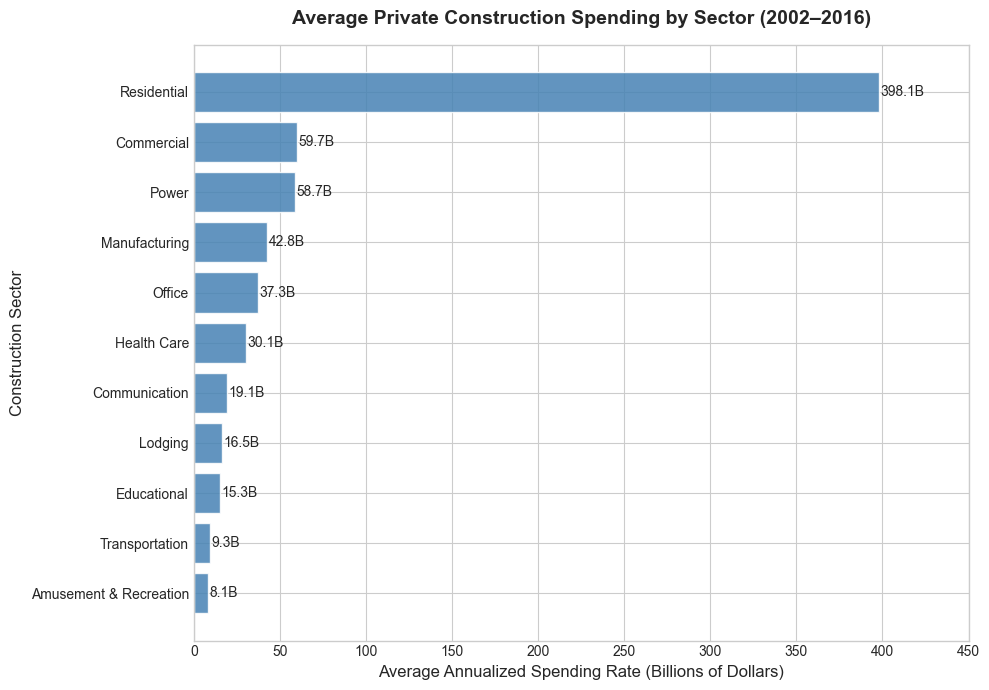

In [8]:
# --- Plot 04: Horizontal Bar Chart — Average Private Sector Spending by Sector ---
# Question: Which private construction sectors receive the most investment on average?

# Define the key private sectors and their clean labels
sectors = {
    'annual.private.residential': 'Residential',
    'annual.private.office': 'Office',
    'annual.private.commercial': 'Commercial',
    'annual.private.manufacturing': 'Manufacturing',
    'annual.private.power': 'Power',
    'annual.private.health care': 'Health Care',
    'annual.private.lodging': 'Lodging',
    'annual.private.educational': 'Educational',
    'annual.private.transportation': 'Transportation',
    'annual.private.amusement and recreation': 'Amusement & Recreation',
    'annual.private.communication': 'Communication'
}

# Calculate means in billions and sort
means = (df[list(sectors.keys())].mean() / 1000).rename(sectors).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(means.index, means.values, color='steelblue',
               edgecolor='white', alpha=0.85)

# Add value labels on each bar
for bar, val in zip(bars, means.values):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}B', va='center', fontsize=10)

# Labels and formatting
ax.set_title('Average Private Construction Spending by Sector (2002–2016)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Average Annualized Spending Rate (Billions of Dollars)', fontsize=12)
ax.set_ylabel('Construction Sector', fontsize=12)
ax.set_xlim(0, 450)

plt.tight_layout()
plt.show()

### Plot 4 Observations — Average Private Spending by Sector

The ranking of private construction sectors by average annualized spending rate reveals a 
striking pattern with major implications for developer decision-making:

- **Residential (398.1B)** completely dominates private construction investment, 
representing nearly **6x the next largest sector** — confirming that housing is by 
far the largest driver of private construction activity
- **Commercial (59.7B)** and **Power (58.7B)** are virtually tied for second, 
suggesting these two sectors compete for similar pools of private capital
- **Manufacturing (42.8B)** and **Office (37.3B)** form a mid-tier of significant 
but secondary commercial investment
- **Health Care (30.1B)** shows relatively stable investment
- The bottom tier — Lodging, Educational, Transportation, and Amusement — each 
average under 20B, representing niche but consistent investment categories

This ranking establishes the baseline hierarchy of developer priorities across the 
full 14-year period. The key question going forward is whether this ranking holds 
during recessions, or whether some sectors prove more resilient than others.

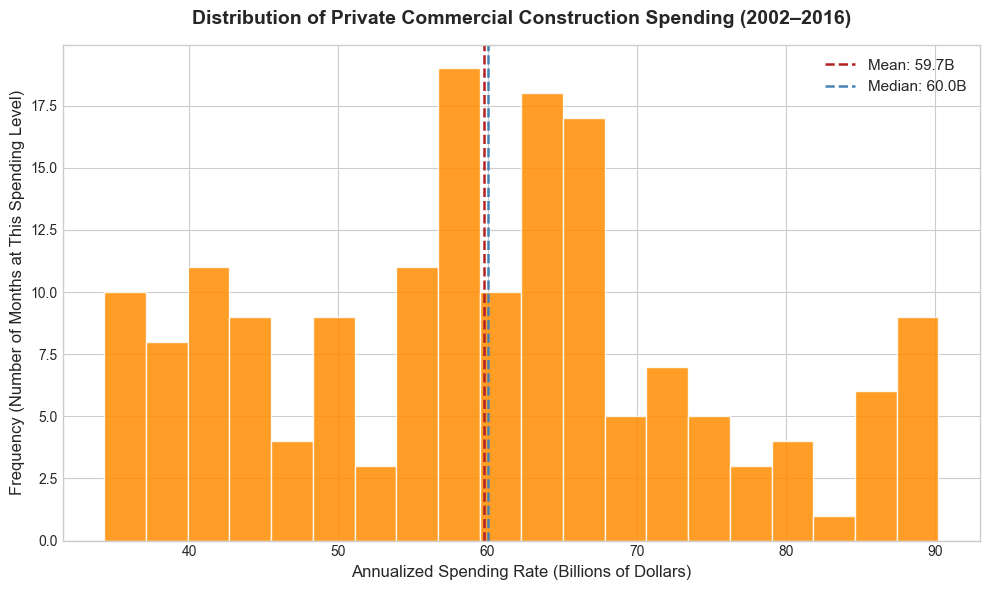

In [9]:
# --- Plot 05: Histogram — Distribution of Private Commercial Spending ---
# Question: How is private commercial spending distributed — does it cluster
# around a central value or spread widely like office spending?

# Convert to billions
commercial_billions = df['annual.private.commercial'] / 1000

fig, ax = plt.subplots(figsize=(10, 6))

# Plot histogram
ax.hist(commercial_billions, bins=20, color='darkorange', edgecolor='white', alpha=0.85)

# Add mean and median reference lines
mean_val = commercial_billions.mean()
median_val = commercial_billions.median()
ax.axvline(mean_val, color='firebrick', linestyle='--', linewidth=1.8,
           label=f'Mean: {mean_val:.1f}B')
ax.axvline(median_val, color='steelblue', linestyle='--', linewidth=1.8,
           label=f'Median: {median_val:.1f}B')

# Labels and formatting
ax.set_title('Distribution of Private Commercial Construction Spending (2002–2016)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Annualized Spending Rate (Billions of Dollars)', fontsize=12)
ax.set_ylabel('Frequency (Number of Months at This Spending Level)', fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

### Plot 5 Observations — Private Commercial Spending Distribution

In contrast to the bimodal office spending distribution, private commercial 
construction spending shows a more **centrally concentrated distribution** with 
a clear peak around 58–65B:

- The mean (59.7B) and median (60.0B) are nearly identical, indicating a 
**symmetric, unimodal distribution** with no significant skew
- The distribution spans from roughly 34B to 90B — a wide range, but most 
months cluster tightly around the central peak
- The right tail (75B–90B) is thinner than expected, suggesting commercial 
spending rarely reaches extreme highs even during boom years
- Unlike office spending, commercial investment appears more **stable and 
predictable** across economic cycles — developers may view commercial space 
as a steadier investment than office buildings

Comparing Plots 1 and 5, office spending is more volatile and cycle-sensitive 
while commercial spending is more consistent — a meaningful distinction for 
developers choosing between these two asset classes.

### Discuss the distribution(s) of your variable(s) of interest. Were there any unusual points? Did you need to perform any transformations?

The three histograms (Plots 1, 2, and 5) revealed that private construction 
spending distributions are shaped heavily by the 2008 recession. Office and total 
private spending both show bimodal distributions reflecting two distinct market 
regimes — high investment during boom years and low investment during recession 
and recovery. Commercial spending was the exception, showing a more symmetric, 
unimodal distribution suggesting greater stability across cycles.

The most unusual finding was the incomplete 2016 data (only 1 month recorded, 
discovered in Plot 3), which will be treated as a partial year in all subsequent 
trend analysis. No transformations were required — all spending values were 
converted from millions to billions for readability, but the underlying data 
required no cleaning as there were no null values or outliers requiring removal.

### Of the features you investigated, were there any unusual distributions? Did you perform any operations on the data to tidy, adjust, or change the form of the data? If so, why did you do this?

The most notable operation performed was the **engineering of the `era` column**,
which classified each of the 169 months into one of four economic periods. This
was done to enable meaningful comparisons across market conditions in subsequent
bivariate and multivariate analysis. Additionally, all spending values were divided
by 1000 to convert from millions to billions of dollars for cleaner visualization.
No rows were dropped and no imputation was needed given the complete dataset.

## Bivariate Exploration

In this section, I examine relationships between pairs of variables to understand 
how private construction sectors interact with each other and how they behave 
across time and economic conditions.

**Assumptions going in:**
- Office and commercial spending may show some correlation since both serve 
business activity, but commercial is expected to be more stable — meaning 
the relationship may weaken or diverge significantly during recession years
- The 2008 recession should be clearly visible as a sharp drop in time series plots
- Public spending may move inversely to private spending during downturns as 
government stimulus fills the gap
- Residential spending likely follows its own cycle, driven by housing demand 
rather than business investment decisions

**Questions this section will answer:**
1. How has total private construction spending changed over time — where does 
the recession hit and when does recovery begin?
2. How does residential spending compare to key commercial sectors across 
economic eras — does housing follow the same recession pattern?
3. How does the distribution of office spending differ across the four economic eras?
4. Which private sectors show the most volatility across economic eras?
5. How does average spending compare across sectors year by year?
6. How does private vs. public total spending compare across the four eras?

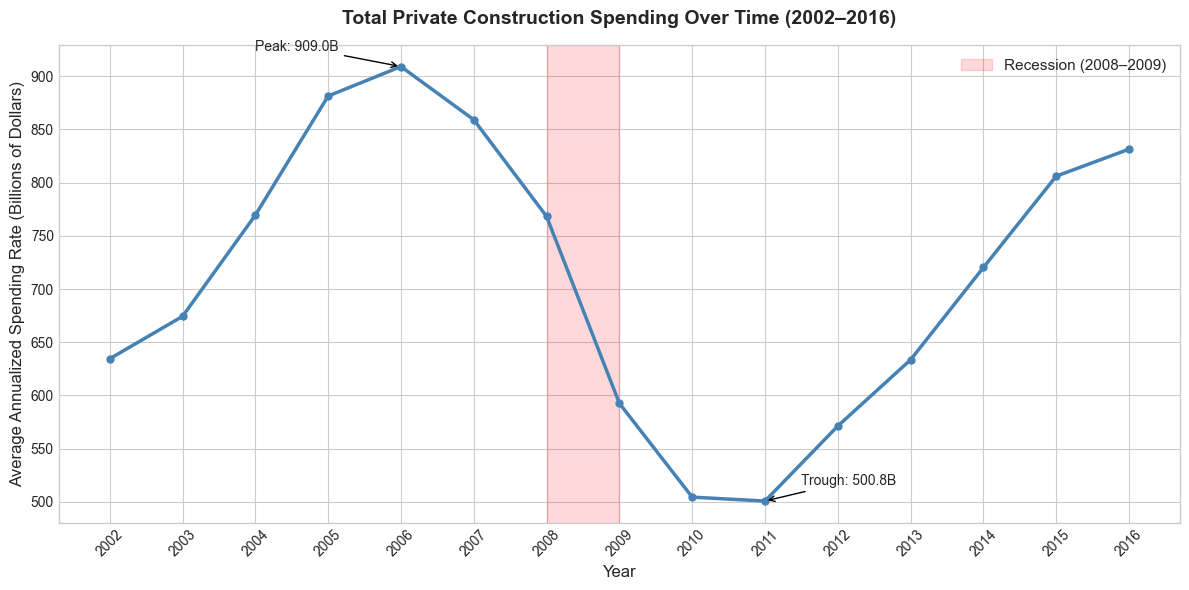

In [10]:
# --- Plot 6: Line Plot — Total Private Construction Spending Over Time ---
# Question: How has total private construction spending changed over time?
# Where does the recession hit and when does recovery begin?

# Calculate annual mean spending in billions
annual_private = df.groupby('time.year')['annual.private.total construction'].mean() / 1000

fig, ax = plt.subplots(figsize=(12, 6))

# Plot line
ax.plot(annual_private.index, annual_private.values, 
        color='steelblue', linewidth=2.5, marker='o', markersize=5)

# Shade recession period
ax.axvspan(2008, 2009, alpha=0.15, color='red', label='Recession (2008–2009)')

# Annotate peak and trough
peak_year = annual_private.idxmax()
trough_year = annual_private.idxmin()
ax.annotate(f'Peak: {annual_private[peak_year]:.1f}B',
            xy=(peak_year, annual_private[peak_year]),
            xytext=(peak_year - 2, annual_private[peak_year] + 15),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10)
ax.annotate(f'Trough: {annual_private[trough_year]:.1f}B',
            xy=(trough_year, annual_private[trough_year]),
            xytext=(trough_year + 0.5, annual_private[trough_year] + 15),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10)

# Labels and formatting
ax.set_title('Total Private Construction Spending Over Time (2002–2016)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Average Annualized Spending Rate (Billions of Dollars)', fontsize=12)
ax.set_xticks(annual_private.index)
ax.set_xticklabels(annual_private.index, rotation=45)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

### Plot 6 Observations — Total Private Construction Spending Over Time

This time series reveals the full arc of private construction investment across 
the 14-year period with striking clarity:

- Private spending **peaked at 909B in 2006**, driven by the pre-recession 
housing boom and strong commercial investment across all sectors
- The recession triggered a **massive 45% decline** from peak to trough, 
with spending bottoming out at 500.8B in 2011 — two years after the 
official recession ended, confirming that construction recovery lags 
the broader economy
- The **recovery was slow but consistent** from 2011 onward, with spending 
climbing steadily back toward 830B by 2016 — still below the 2006 peak
- Note that 2016 represents only one month of data and likely understates 
the true annual spending level for that year

For developers, this chart illustrates the critical importance of timing 
market entry — those who committed to large projects at the 2006 peak faced 
dramatically different conditions than those who entered during the 2011–2013 
recovery window.

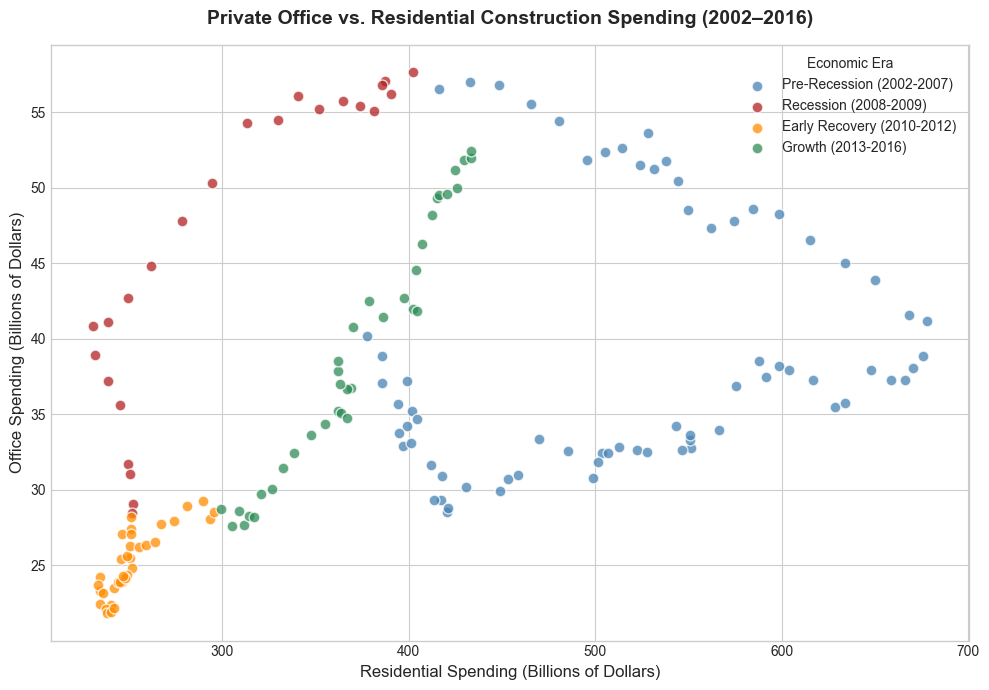

In [11]:
# --- Plot 7: Scatterplot — Private Office vs. Private Residential Spending ---
# Question: How does residential spending compare to office spending —
# do they follow the same cycle or diverge during recessions?

# Convert to billions
office_b = df['annual.private.office'] / 1000
residential_b = df['annual.private.residential'] / 1000

fig, ax = plt.subplots(figsize=(10, 7))

# Plot each era with a different color
colors = {
    'Pre-Recession (2002-2007)': 'steelblue',
    'Recession (2008-2009)': 'firebrick',
    'Early Recovery (2010-2012)': 'darkorange',
    'Growth (2013-2016)': 'seagreen'
}

for era, color in colors.items():
    mask = df['era'] == era
    ax.scatter(residential_b[mask], office_b[mask],
               color=color, label=era, alpha=0.75, s=60, edgecolors='white')

# Labels and formatting
ax.set_title('Private Office vs. Residential Construction Spending (2002–2016)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Residential Spending (Billions of Dollars)', fontsize=12)
ax.set_ylabel('Office Spending (Billions of Dollars)', fontsize=12)
ax.legend(fontsize=10, title='Economic Era', title_fontsize=10)

plt.tight_layout()
plt.show()

### Plot 7 Observations — Office vs. Residential Spending by Era

This scatterplot reveals that residential and office construction spending 
follow **fundamentally different cycles**, with important implications for 
developer timing decisions:

- **Pre-Recession (blue):** Both sectors were simultaneously high — residential 
spending ranged from 400–680B while office held steady at 30–55B, suggesting 
a broad-based construction boom across asset classes
- **Recession (red):** The most revealing cluster — residential collapsed to 
230–420B but office spending remained elevated at 30–57B. This confirms that 
the 2008 crisis was initially a **housing crisis, not a commercial crisis**
- **Early Recovery (orange):** Both sectors hit their lows simultaneously — 
residential stayed depressed while office finally dropped to 22–30B, suggesting 
office construction felt the full impact with a 2–3 year lag
- **Growth (green):** Both sectors show steady recovery, with residential 
climbing back toward 500B and office recovering toward 52B

The key takeaway for developers: **office investment is a lagging indicator** 
relative to residential. Developers who tracked residential as an early warning 
signal could have anticipated the eventual office downturn and adjusted 
their project pipelines accordingly.

C:\Users\jshol\AppData\Local\Temp\ipykernel_9604\1935386943.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['office_billions'] = df['annual.private.office'] / 1000
C:\Users\jshol\AppData\Local\Temp\ipykernel_9604\1935386943.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(data=df, x='era', y='office_billions',
C:\Users\jshol\AppData\Local\Temp\ipykernel_9604\1935386943.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label.get_text().replace(' (', '\n(')


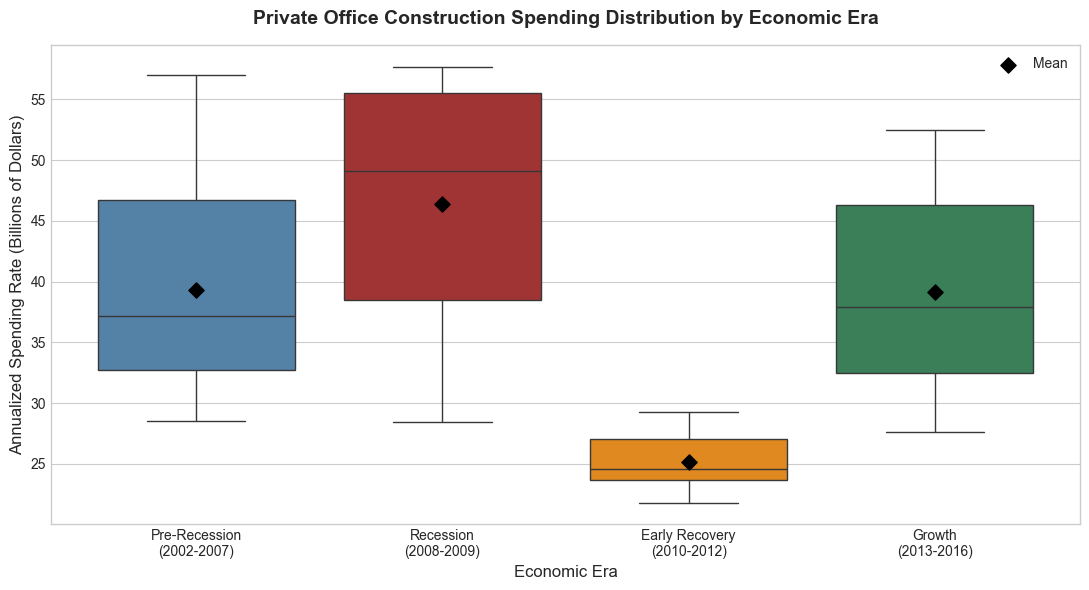

In [12]:
# --- Plot 8: Box Plot — Private Office Spending Distribution by Era ---
# Question: How does the distribution of office spending differ across
# the four economic eras?

fig, ax = plt.subplots(figsize=(11, 6))

# Convert to billions
df['office_billions'] = df['annual.private.office'] / 1000

sb.boxplot(data=df, x='era', y='office_billions',
           order=era_order, palette=['steelblue', 'firebrick',
                                     'darkorange', 'seagreen'],
           ax=ax)

# Add mean markers with visible color
era_means = df.groupby('era')['office_billions'].mean()
for i, era in enumerate(era_order):
    ax.scatter(i, era_means[era], color='black', s=60,
               zorder=5, marker='D', label='Mean' if i == 0 else '')

# Labels and formatting
ax.set_title('Private Office Construction Spending Distribution by Economic Era',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Economic Era', fontsize=12)
ax.set_ylabel('Annualized Spending Rate (Billions of Dollars)', fontsize=12)
ax.legend(fontsize=10)

# Wrap x-axis labels for readability
ax.set_xticklabels([label.get_text().replace(' (', '\n(')
                    for label in ax.get_xticklabels()], fontsize=10)

plt.tight_layout()
plt.show()

### Plot 8 Observations — Office Spending Distribution by Economic Era

The box plots reveal a surprising and counterintuitive pattern in office 
construction spending across economic eras:

- **Pre-Recession (2002–2007):** Wide spread (28–55B) with a mean around 39B, 
reflecting the gradual build-up of the boom years with high variability
- **Recession (2008–2009):** Surprisingly, the median and mean are the HIGHEST 
of all four eras (~46–50B range), confirming that office construction investment 
actually peaked during the early recession period — developers were still 
completing projects committed before the crash
- **Early Recovery (2010–2012):** The sharpest drop — spending compressed into 
a very tight range of 22–30B with minimal variance, reflecting a period of 
near-complete halt in new office development
- **Growth (2013–2016):** Recovery is visible with the range expanding back to 
28–52B, though the median remains below pre-recession levels

The key insight: **office spending lags the economic cycle by 2–3 years** in 
both directions — developers cannot instantly stop or start large projects, 
so spending momentum carries forward even as conditions change.

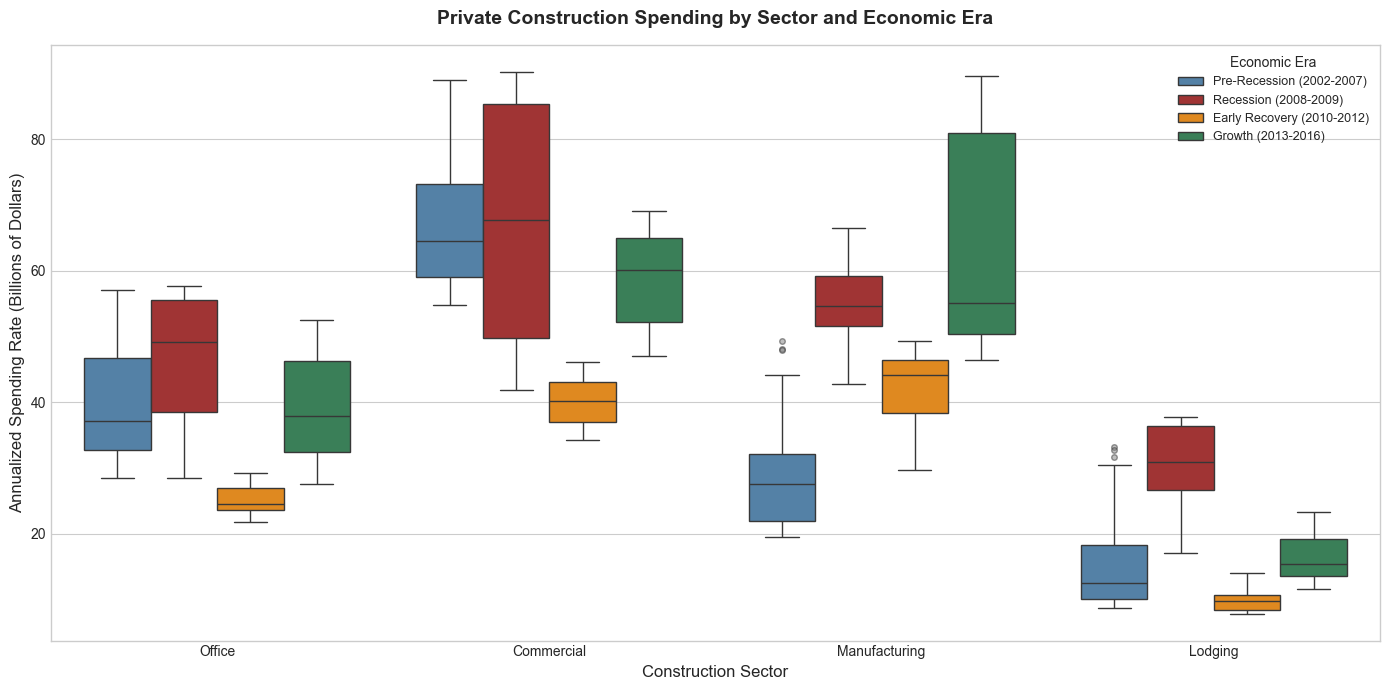

In [13]:
# --- Plot 9: Box Plot — Multiple Sectors by Era ---
# Question: Which private sectors show the most volatility across economic eras?

sectors_of_interest = {
    'annual.private.office': 'Office',
    'annual.private.commercial': 'Commercial',
    'annual.private.manufacturing': 'Manufacturing',
    'annual.private.lodging': 'Lodging'
}

# Build a long-format dataframe
rows = []
for col, label in sectors_of_interest.items():
    for _, row in df.iterrows():
        rows.append({'Era': row['era'], 'Sector': label,
                     'Spending': row[col] / 1000})
df_long = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(14, 7))

sb.boxplot(data=df_long, x='Sector', y='Spending', hue='Era',
           hue_order=era_order,
           palette=['steelblue', 'firebrick', 'darkorange', 'seagreen'],
           flierprops=dict(marker='o', markerfacecolor='gray',
                          markersize=4, alpha=0.5),
           ax=ax)

# Labels and formatting
ax.set_title('Private Construction Spending by Sector and Economic Era',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Construction Sector', fontsize=12)
ax.set_ylabel('Annualized Spending Rate (Billions of Dollars)', fontsize=12)
ax.legend(title='Economic Era', fontsize=9, title_fontsize=10,
          loc='upper right')

plt.tight_layout()
plt.show()

### Plot 9 Observations — Sector Volatility Across Economic Eras

Comparing four key private sectors across economic eras reveals dramatically 
different levels of cycle sensitivity:

- **Commercial** is the most volatile sector overall — the recession box 
(red) sits significantly higher than all other eras, with a wide spread 
reaching 85B, confirming that commercial projects already in pipeline 
continued through the early recession
- **Manufacturing** shows the most dramatic era-to-era swings — low during 
Pre-Recession, very high during Recession, moderate in Recovery, then 
surging again in Growth, suggesting manufacturing investment is driven by 
industrial cycles that don't perfectly align with the broader economy
- **Office** follows the lagged pattern identified in Plot 8 — high during 
Recession, then crashing in Early Recovery before recovering in Growth
- **Lodging** is the most compressed and consistent sector — all four era 
boxes are relatively small and low, suggesting hotel/hospitality development 
is a niche, stable investment category less sensitive to broad economic cycles
- The small gray dots above Manufacturing (Pre-Recession) and Lodging 
(Recession) represent outlier months where spending briefly spiked 
beyond the typical range for that era

Overall, Commercial and Manufacturing show the highest volatility, making 
them higher-risk but potentially higher-reward sectors for developers 
with strong market timing.

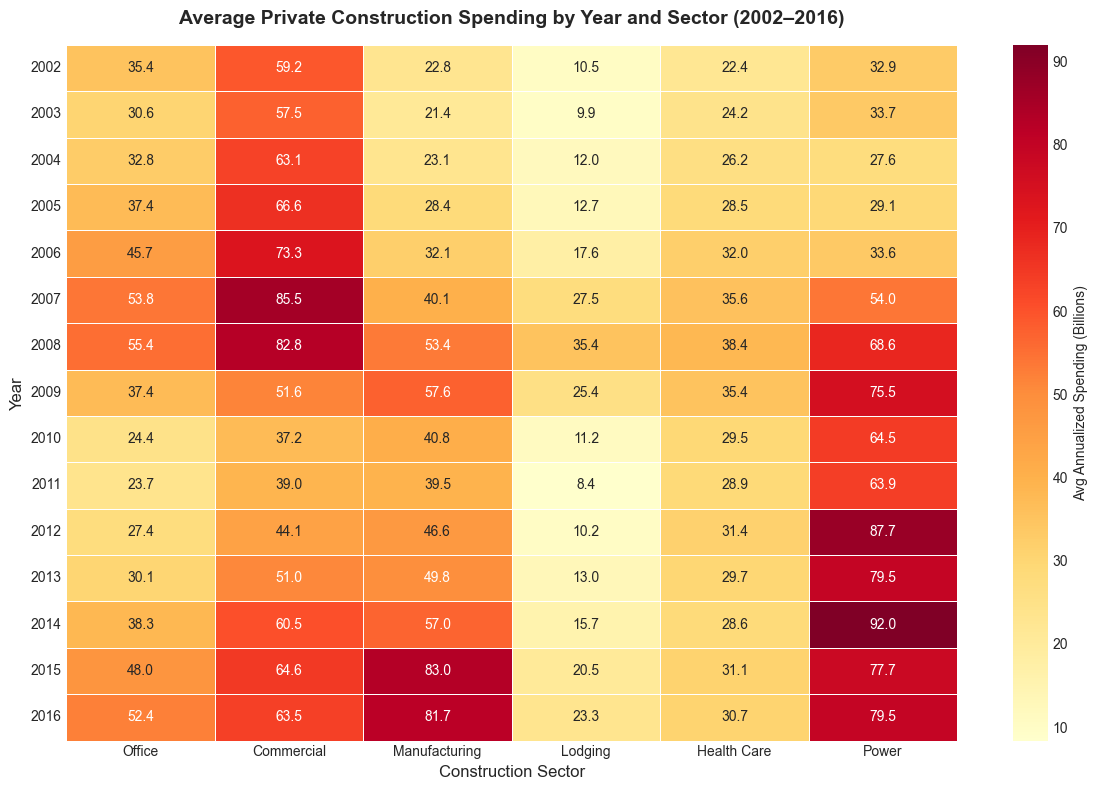

In [14]:
# --- Plot 10: Heatmap — Average Private Sector Spending by Year ---
# Question: How does average private sector spending vary by year across
# all commercial sectors — which year-sector combinations stand out?

# Define sectors and their short labels
sectors = {
    'annual.private.office': 'Office',
    'annual.private.commercial': 'Commercial',
    'annual.private.manufacturing': 'Manufacturing',
    'annual.private.lodging': 'Lodging',
    'annual.private.health care': 'Health Care',
    'annual.private.power': 'Power'
}

# Build year x sector pivot table in billions
pivot = df.groupby('time.year')[list(sectors.keys())].mean() / 1000
pivot.columns = list(sectors.values())

fig, ax = plt.subplots(figsize=(12, 8))

sb.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
           linewidths=0.5, linecolor='white',
           cbar_kws={'label': 'Avg Annualized Spending (Billions)'},
           ax=ax)

# Labels and formatting
ax.set_title('Average Private Construction Spending by Year and Sector (2002–2016)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Construction Sector', fontsize=12)
ax.set_ylabel('Year', fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

### Plot 10 Observations — Sector Spending Heatmap by Year

This heatmap provides the clearest single view of how developer investment 
priorities shifted year by year across six key sectors:

- **Office** peaked in 2007–2008 (55.4B) then fell sharply through 2011 
(23.7B) before recovering — the darkest cells are at the top and bottom 
of the timeline, with a clear pale band in 2010–2012
- **Commercial** followed a similar pattern, peaking at 85.5B in 2007 
then dropping to 37–39B during recovery before climbing back to 64B by 2016
- **Manufacturing** tells a completely different story — spending was 
relatively LOW pre-recession (22–40B), then SURGED post-2012, reaching 
83B in 2015 — the darkest cells are at the BOTTOM of the column, 
suggesting an industrial investment boom during the recovery period
- **Lodging** was consistently low throughout, with a modest peak in 
2007–2008 (27–35B) and recovery back toward 23B by 2016
- **Health Care** remained remarkably stable across all years (28–38B), 
confirming it as the most recession-resistant sector in the dataset
- **Power** shows a striking pattern — relatively stable early on, 
then surging dramatically after 2009 to reach 92B in 2014, likely 
reflecting major energy infrastructure investment during the recovery

The heatmap confirms that no two sectors follow identical investment 
cycles, giving developers clear signals about which sectors to favor 
at different points in the economic cycle.

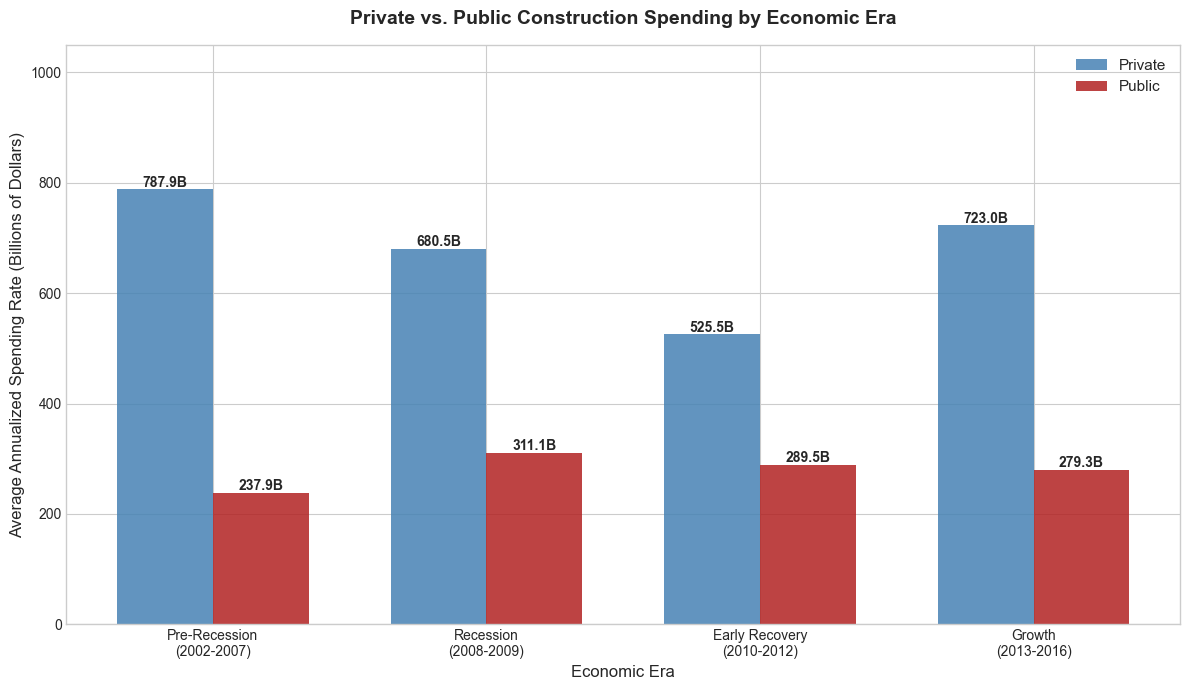

In [15]:
# --- Plot 11: Clustered Bar Chart — Private vs. Public Spending by Era ---
# Question: How does private vs. public total spending compare across the four eras?

# Calculate mean spending by era in billions
private_by_era = df.groupby('era')['annual.private.total construction'].mean() / 1000
public_by_era = df.groupby('era')['annual.public.total construction'].mean() / 1000

# Set up bar positions
x = np.arange(len(era_order))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

bars1 = ax.bar(x - width/2, [private_by_era[e] for e in era_order],
               width, label='Private', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, [public_by_era[e] for e in era_order],
               width, label='Public', color='firebrick', alpha=0.85)

# Annotate bar values
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{bar.get_height():.1f}B', ha='center', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{bar.get_height():.1f}B', ha='center', fontsize=10, fontweight='bold')

# Labels and formatting
ax.set_title('Private vs. Public Construction Spending by Economic Era',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Economic Era', fontsize=12)
ax.set_ylabel('Average Annualized Spending Rate (Billions of Dollars)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([e.replace(' (', '\n(') for e in era_order], fontsize=10)
ax.legend(fontsize=11)
ax.set_ylim(0, 1050)

plt.tight_layout()
plt.show()

### Plot 11 Observations — Private vs. Public Spending by Era

This clustered bar chart reveals one of the most important findings for 
understanding developer decision-making in context:

- **Pre-Recession:** Private investment (787.9B) dwarfs public spending 
(237.9B) — a ratio of roughly 3.3:1, reflecting a fully private-led 
construction market
- **Recession:** Private spending drops significantly to 680.5B while 
public spending INCREASES to 311.1B — the government actively expanded 
construction investment as private developers pulled back, consistent 
with stimulus spending policies of 2008–2009
- **Early Recovery:** Private hits its lowest point at 525.5B while 
public remains elevated at 289.5B — the ratio narrows to 1.8:1, meaning 
government was shouldering a much larger share of total construction 
activity than at any other point in the dataset
- **Growth:** Private recovers strongly to 723.0B while public begins 
declining to 279.3B — the market returns toward private leadership as 
confidence rebuilds

The inverse relationship between private and public spending confirms 
the **countercyclical nature of government construction investment** — 
public spending acts as a stabilizing floor when private developers 
retreat, a critical insight for understanding total market conditions 
across economic cycles.

### Talk about some of the relationships you observed in this part of the investigation. How did the feature(s) of interest vary with other features in the dataset?

The bivariate exploration revealed several critical relationships between 
private construction spending and other variables:

- **Private spending vs. time (Plot 6):** Total private construction followed 
a clear boom-bust-recovery cycle, peaking at 909B in 2006 and bottoming at 
500.8B in 2011 — a 45% decline driven by the financial crisis
- **Office vs. residential (Plot 7):** These two sectors follow fundamentally 
different cycles. Residential collapsed immediately in 2008 while office 
spending held up, confirming the crisis was initially housing-driven. Office 
then crashed with a 2–3 year lag during the Early Recovery era
- **Office spending by era (Plot 8):** The counterintuitive finding that office 
spending was highest during the Recession era confirms that large commercial 
projects cannot be stopped instantly — spending momentum carries forward 
even as market conditions deteriorate
- **Sector volatility (Plot 9):** Commercial and Manufacturing showed the 
highest volatility across eras, while Health Care and Lodging remained 
relatively stable — meaningful signals for risk-averse vs. risk-tolerant developers

### Did you observe any interesting relationships between the other features (not the main feature(s) of interest)?

Two particularly interesting relationships emerged between supporting features:

- **Public vs. private spending (Plot 11):** The inverse relationship between 
public and private construction spending across eras was striking — as private 
investment fell during the recession, public spending rose from 237.9B to 
311.1B, acting as a countercyclical stabilizer. This government backstop 
partially offset private retreat and kept total construction activity from 
collapsing entirely
- **Power sector anomaly (Plot 10):** Power construction spending surged 
dramatically after 2009, reaching 92B in 2014 — completely independent of 
the broader recession pattern. This suggests energy infrastructure investment 
follows its own investment cycle, driven by regulatory and energy policy 
factors rather than general economic conditions

## Multivariate Exploration

In this section, I examine relationships between three or more variables 
simultaneously to uncover deeper patterns in how private construction 
sectors interact across time and economic conditions.

**Assumptions going in:**
- Sectors that behaved similarly in bivariate analysis likely cluster 
together in multivariate space — office and commercial may correlate 
strongly while manufacturing and power follow independent paths
- The era encoding should reveal distinct investment clusters when 
multiple sectors are plotted together
- Faceting by sector should confirm the lagged recession pattern 
observed in bivariate analysis across all sectors simultaneously

**Questions this section will answer:**
1. How does each key private sector's spending trend over time — do all 
sectors follow the same recession pattern or do some diverge?
2. When plotting office vs. commercial spending colored by era, do 
distinct investment clusters emerge that reflect different market conditions?
3. Across eras, how do the top private sectors shift relative to each other?
4. Which private sectors move together — are there correlation clusters 
that reveal how developers bundle investment decisions?
5. Which sectors led the pre-recession boom and which led the recovery?

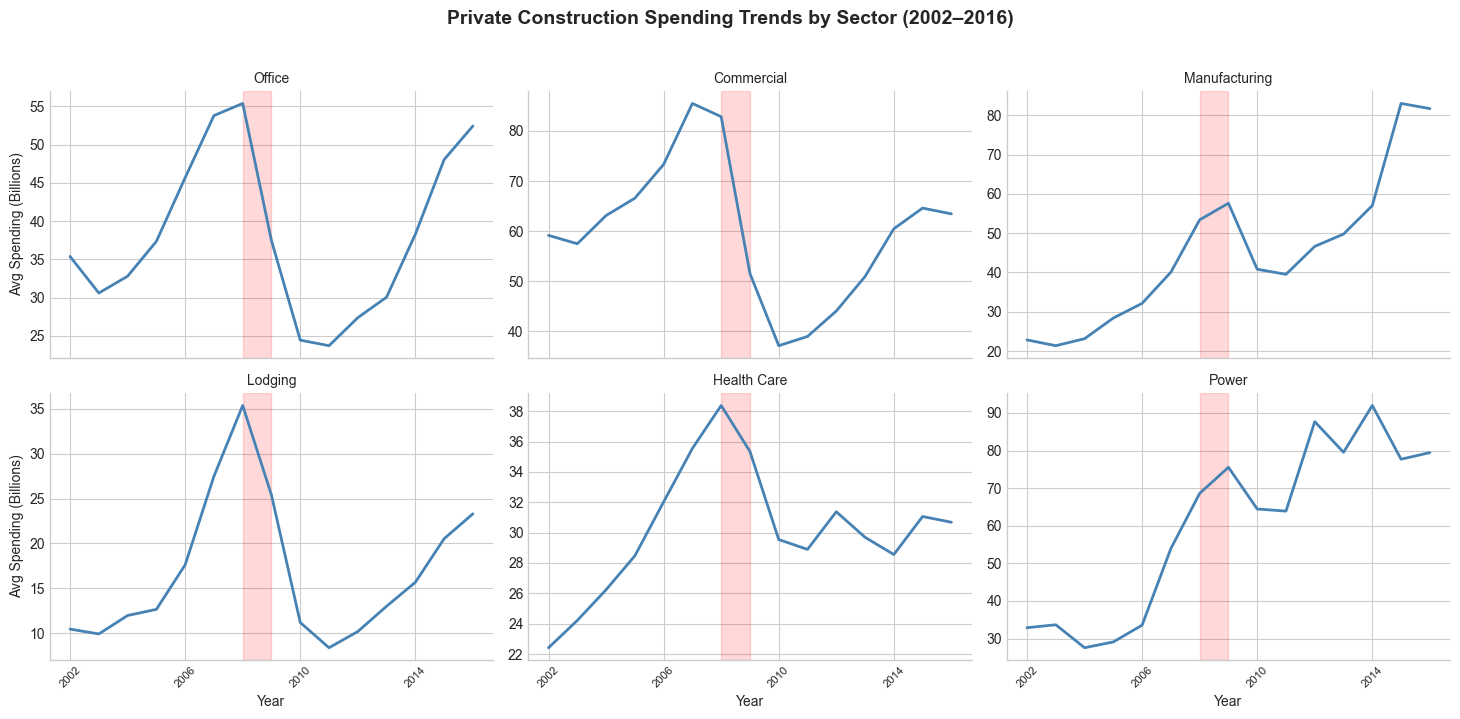

In [16]:
# --- Plot 12: Facet Plot — Each Sector's Spending Trend Over Time ---
# Question: How does each key private sector trend over time — do all sectors
# follow the same recession pattern or do some diverge?

# Define sectors and labels
sectors = {
    'annual.private.office': 'Office',
    'annual.private.commercial': 'Commercial',
    'annual.private.manufacturing': 'Manufacturing',
    'annual.private.lodging': 'Lodging',
    'annual.private.health care': 'Health Care',
    'annual.private.power': 'Power'
}

# Build long format dataframe with annual means
rows = []
for col, label in sectors.items():
    yearly = df.groupby('time.year')[col].mean() / 1000
    for year, val in yearly.items():
        rows.append({'Year': year, 'Sector': label, 'Spending': val})
df_facet = pd.DataFrame(rows)

# Create facet grid
g = sb.FacetGrid(df_facet, col='Sector', col_wrap=3,
                 height=3.5, aspect=1.4, sharey=False)
g.map_dataframe(sb.lineplot, x='Year', y='Spending',
                color='steelblue', linewidth=2)

# Add recession shading to each facet
for ax in g.axes.flat:
    ax.axvspan(2008, 2009, alpha=0.15, color='red')
    ax.set_xticks([2002, 2006, 2010, 2014])
    ax.set_xticklabels([2002, 2006, 2010, 2014], rotation=45, fontsize=8)

# Labels and formatting
g.set_axis_labels('Year', 'Avg Spending (Billions)')
g.set_titles(col_template='{col_name}')
g.figure.suptitle('Private Construction Spending Trends by Sector (2002–2016)',
                  fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

### Plot 12 Observations — Sector Spending Trends by Facet

Viewing all six sectors simultaneously in a faceted layout reveals that 
**no two sectors follow identical patterns** across the 14-year period:

- **Office and Commercial** share the most similar shape — both peak 
around 2006–2007, dip during the recession band, and gradually recover 
toward 2016, though neither fully returns to pre-recession peaks
- **Manufacturing** is strikingly different — relatively flat pre-recession, 
a brief spike during 2008–2009, then a dramatic upward surge from 2012 
onward reaching new highs by 2015–2016, suggesting post-recession 
industrial expansion driven by reshoring and energy sector demand
- **Lodging** shows the sharpest single-cycle pattern — a clean peak in 
2007–2008 followed by a steep crash and slow recovery, reflecting the 
hospitality industry's direct dependence on business travel and consumer 
confidence
- **Health Care** is the flattest line of all six panels — spending moves 
within a narrow 22–38B band throughout the entire period, confirming its 
status as the most recession-resistant sector in the dataset
- **Power** shows the most unusual pattern — low and flat pre-recession, 
then a massive surge from 2009 onward peaking around 2012–2014, completely 
decoupled from the broader construction cycle

The facet plot confirms that developers cannot treat the construction 
market as monolithic — sector selection is as important as market timing.

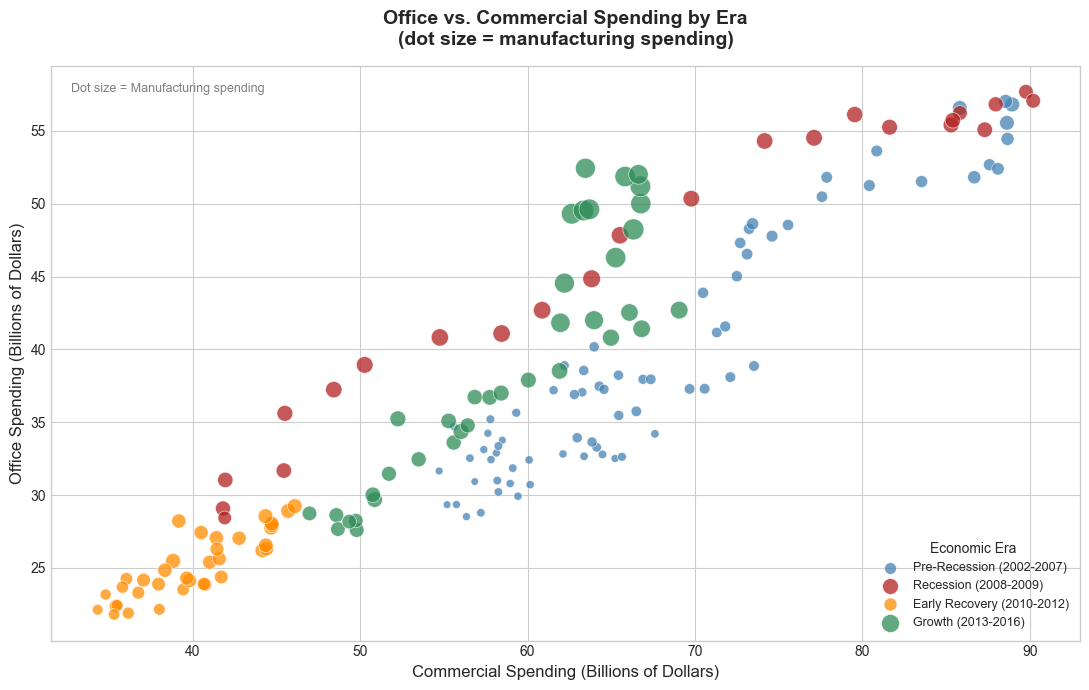

In [17]:
# --- Plot 13: Scatterplot with Multiple Encodings ---
# Question: When plotting office vs. commercial spending colored by era,
# do distinct investment clusters emerge?

fig, ax = plt.subplots(figsize=(11, 7))

# Convert to billions
office_b = df['annual.private.office'] / 1000
commercial_b = df['annual.private.commercial'] / 1000
manufacturing_b = df['annual.private.manufacturing'] / 1000

# Scale manufacturing for dot size (normalize to reasonable range)
size_scaled = ((manufacturing_b - manufacturing_b.min()) /
               (manufacturing_b.max() - manufacturing_b.min()) * 200) + 30

colors = {
    'Pre-Recession (2002-2007)': 'steelblue',
    'Recession (2008-2009)': 'firebrick',
    'Early Recovery (2010-2012)': 'darkorange',
    'Growth (2013-2016)': 'seagreen'
}

for era, color in colors.items():
    mask = df['era'] == era
    ax.scatter(commercial_b[mask], office_b[mask],
               c=color, s=size_scaled[mask],
               label=era, alpha=0.75, edgecolors='white', linewidth=0.5)

# Add size legend note
ax.text(0.02, 0.97, 'Dot size = Manufacturing spending',
        transform=ax.transAxes, fontsize=9,
        verticalalignment='top', color='gray')

# Labels and formatting
ax.set_title('Office vs. Commercial Spending by Era\n(dot size = manufacturing spending)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Commercial Spending (Billions of Dollars)', fontsize=12)
ax.set_ylabel('Office Spending (Billions of Dollars)', fontsize=12)
ax.legend(title='Economic Era', fontsize=9, title_fontsize=10)

plt.tight_layout()
plt.show()

### Plot 13 Observations — Office vs. Commercial Spending with Era and Manufacturing Encoding

This three-variable scatterplot reveals distinct investment clusters for 
each economic era, confirming that market conditions create recognizable 
"investment regimes" that developers operate within:

- **Early Recovery (orange):** Tightly clustered in the bottom-left — 
both office and commercial spending were simultaneously depressed (38–50B 
commercial, 22–30B office) with small dot sizes indicating low manufacturing. 
This represents the most capital-constrained environment in the dataset
- **Pre-Recession (blue):** Spread across the right side — high commercial 
(60–90B) with moderate office (28–48B) and consistently small dots, 
suggesting manufacturing was not a major investment priority during the 
housing-driven boom
- **Recession (red):** Clustered in the upper-left to upper-middle — 
surprisingly high office (30–57B) despite varying commercial, with 
larger dot sizes indicating manufacturing spending was elevated. 
Developers were still completing committed projects
- **Growth (green):** The widest spread of all eras — large dots 
throughout confirming manufacturing surged alongside recovering office 
and commercial investment, suggesting a broad-based multi-sector 
expansion

The three-variable encoding confirms that **manufacturing spending is 
a distinguishing characteristic of the Growth era** — it is what 
separates the post-2013 recovery from the pre-recession boom, where 
office and commercial were high but manufacturing was not.

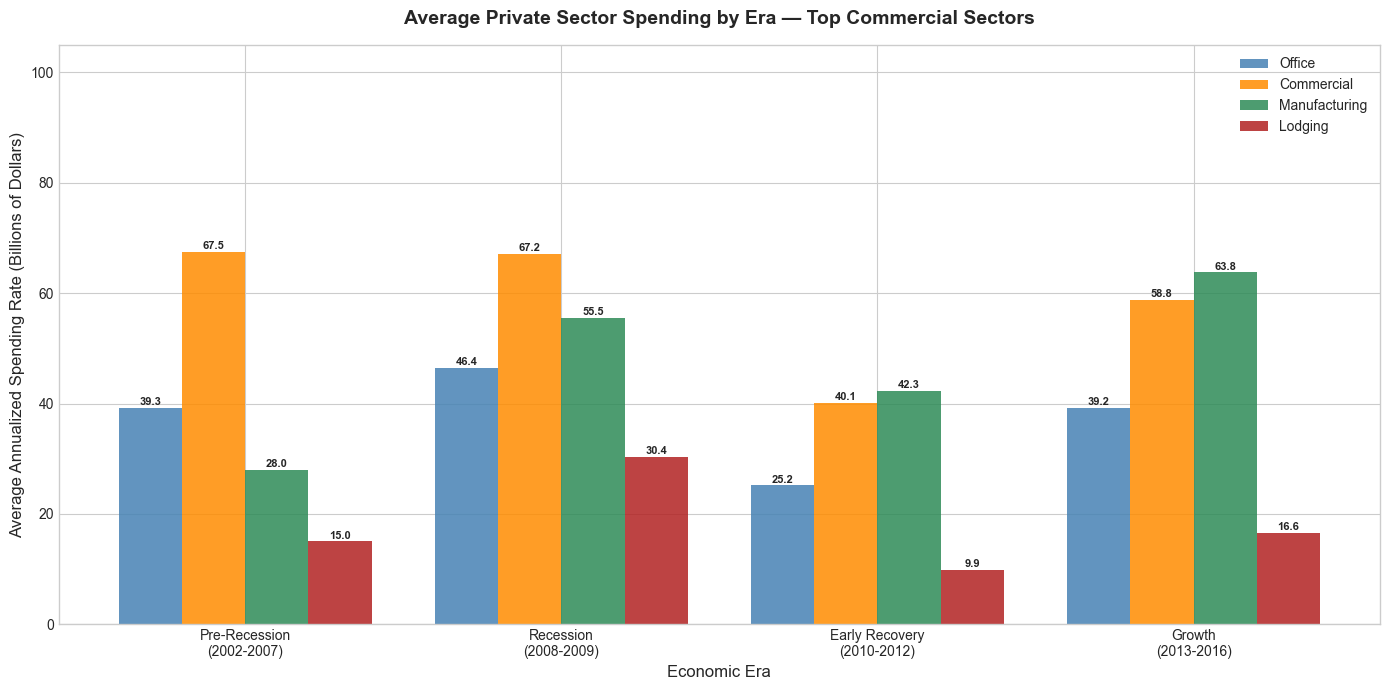

In [18]:
# --- Plot 14: Clustered Bar Chart — Top Sectors by Era ---
# Question: Across eras, how do the top private sectors shift relative to each other?

sectors_14 = {
    'annual.private.office': 'Office',
    'annual.private.commercial': 'Commercial',
    'annual.private.manufacturing': 'Manufacturing',
    'annual.private.lodging': 'Lodging'
}

# Calculate mean by era in billions
era_sector_means = {}
for col, label in sectors_14.items():
    era_sector_means[label] = [
        df[df['era'] == e][col].mean() / 1000 for e in era_order
    ]

x = np.arange(len(era_order))
width = 0.2
fig, ax = plt.subplots(figsize=(14, 7))

colors_14 = ['steelblue', 'darkorange', 'seagreen', 'firebrick']
for i, (label, values) in enumerate(era_sector_means.items()):
    bars = ax.bar(x + i * width, values, width,
                  label=label, color=colors_14[i], alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{bar.get_height():.1f}',
                ha='center', fontsize=8, fontweight='bold')

# Labels and formatting
ax.set_title('Average Private Sector Spending by Era — Top Commercial Sectors',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Economic Era', fontsize=12)
ax.set_ylabel('Average Annualized Spending Rate (Billions of Dollars)', fontsize=12)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([e.replace(' (', '\n(') for e in era_order], fontsize=10)
ax.legend(fontsize=10)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()

### Plot 14 Observations — Top Sector Spending Shifts Across Eras

This clustered bar chart shows how the four key commercial sectors 
repositioned relative to each other across economic eras:

- **Commercial (orange) dominates consistently** across all four eras, 
maintaining the highest spending level in every period — 67.5B 
pre-recession, holding at 67.2B during recession, dropping to 42.3B 
in recovery, then rebounding to 58.8B in growth
- **Manufacturing (green) shows the most dramatic repositioning** — 
starting as the second smallest sector pre-recession (28.9B), surging 
to 55.5B during recession, holding at 42.3B in recovery, then 
exploding to 63.8B in growth to become the TOP sector by the Growth era
- **Office (blue) follows a classic lagged cycle** — relatively stable 
pre-recession (39.3B), slightly higher during recession (46.4B) due 
to project momentum, then crashing to its lowest point in Early 
Recovery (25.2B) before recovering to 39.2B in Growth
- **Lodging (red) remains the smallest sector throughout** — peaking 
at 30.4B during recession and falling to just 9.9B in Early Recovery, 
confirming it as the most dramatically affected niche sector

The most striking finding: **by the Growth era, Manufacturing had 
overtaken Commercial as the largest investment sector** — a complete 
reversal of the pre-recession hierarchy that signals a fundamental 
shift in where private developers were deploying capital.

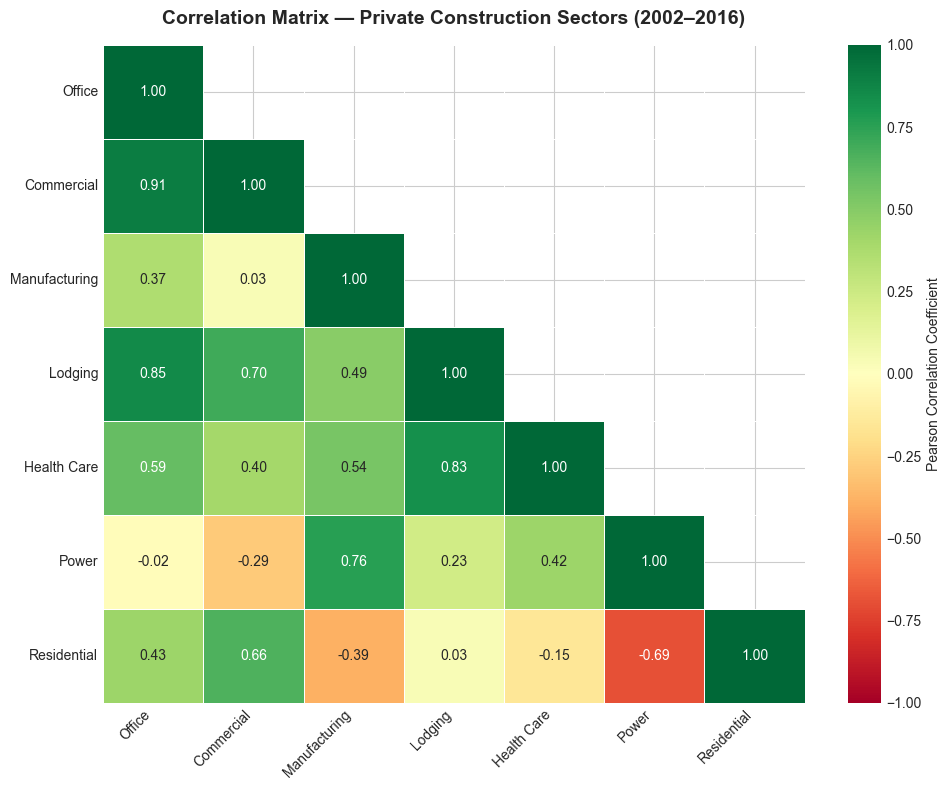

In [19]:
# --- Plot 15: Correlation Matrix Heatmap — Private Sector Relationships ---
# Question: Which private sectors move together — are there correlation
# clusters that reveal how developers bundle investment decisions?

# Select key private sectors
corr_sectors = {
    'annual.private.office': 'Office',
    'annual.private.commercial': 'Commercial',
    'annual.private.manufacturing': 'Manufacturing',
    'annual.private.lodging': 'Lodging',
    'annual.private.health care': 'Health Care',
    'annual.private.power': 'Power',
    'annual.private.residential': 'Residential'
}

# Build correlation matrix
corr_df = df[list(corr_sectors.keys())].rename(columns=corr_sectors)
corr_matrix = corr_df.corr()

# Create mask for upper triangle
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

fig, ax = plt.subplots(figsize=(10, 8))

sb.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
           cmap='RdYlGn', center=0, vmin=-1, vmax=1,
           linewidths=0.5, linecolor='white',
           cbar_kws={'label': 'Pearson Correlation Coefficient'},
           ax=ax)

ax.set_title('Correlation Matrix — Private Construction Sectors (2002–2016)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

### Plot 15 Observations — Private Sector Correlation Matrix

The correlation matrix reveals three distinct clusters of sector 
relationships that reflect how developers bundle investment decisions:

**High positive correlations (move together):**
- **Office and Commercial (0.91)** — the strongest relationship in 
the matrix, confirming these two sectors are driven by the same 
business activity cycle and investor sentiment
- **Lodging and Health Care (0.83)** — a surprising pairing suggesting 
both sectors benefit from similar demographic and service-economy drivers
- **Office and Lodging (0.85)** — hotels and offices both depend on 
business activity, explaining their strong co-movement

**Independent sectors:**
- **Manufacturing and Commercial (0.03)** — essentially zero correlation, 
confirming manufacturing follows industrial cycles completely independent 
of retail/commercial real estate
- **Manufacturing and Office (0.37)** — weak positive relationship, 
suggesting some shared economic drivers but largely independent cycles
- **Power and Office (-0.02)** — virtually no relationship, confirming 
power infrastructure is driven by regulatory and energy policy factors

**Negative correlations (move in opposite directions):**
- **Residential and Power (-0.69)** — the most striking finding: as 
power infrastructure investment surged post-2009, residential was 
declining. These sectors compete for capital in opposite phases
- **Residential and Manufacturing (-0.39)** — moderate negative 
correlation, suggesting industrial and housing investment cycles 
are counter-cyclical to each other

For developers, these correlations define natural **portfolio 
diversification strategies** — pairing Office with Manufacturing 
or Residential with Power provides natural hedges against cycle risk.

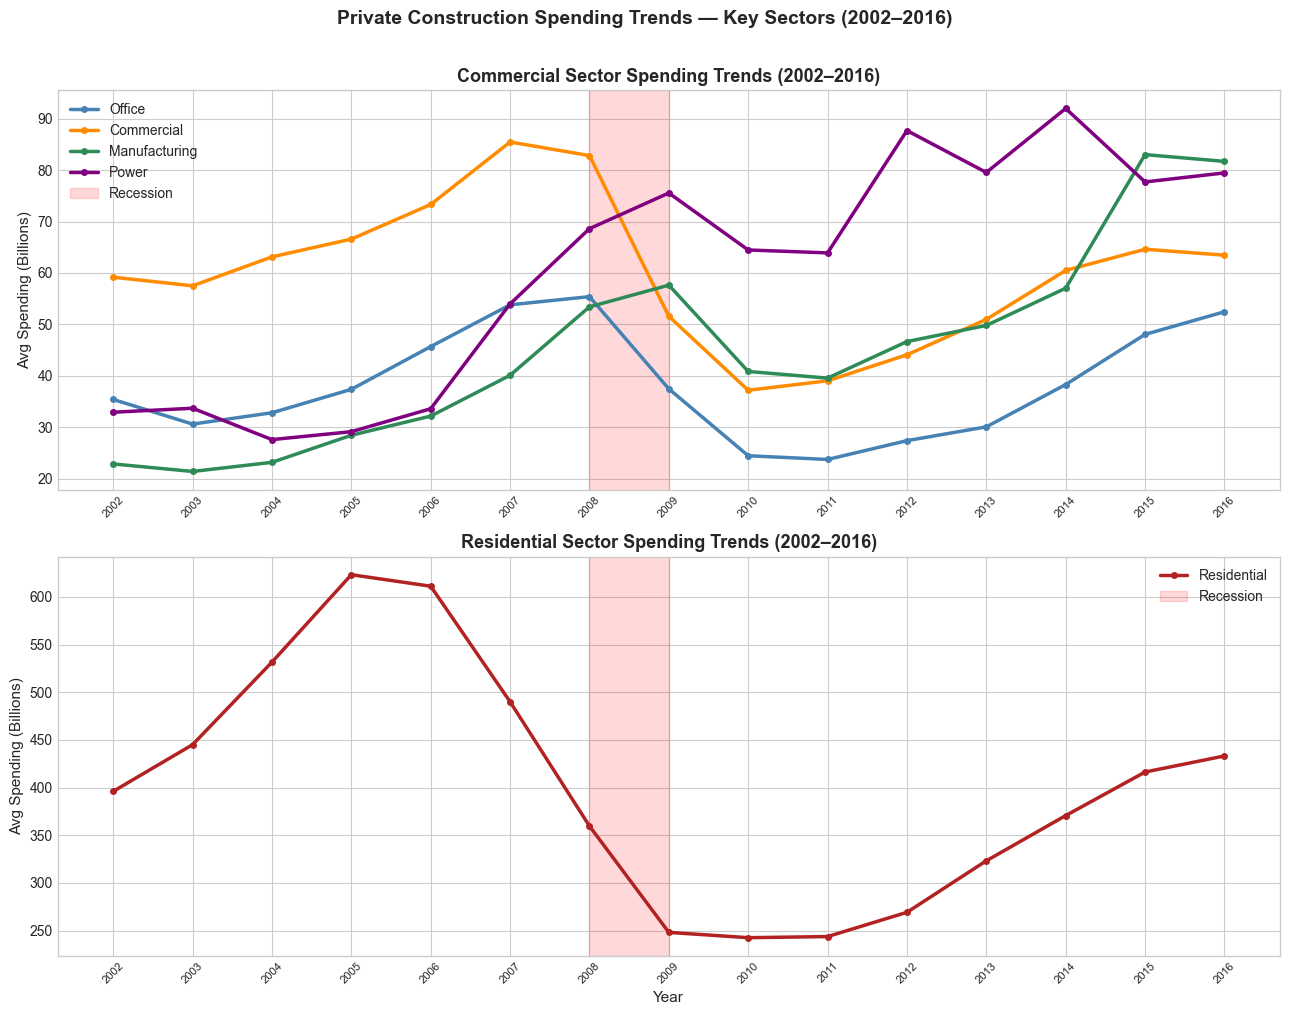

In [20]:
# --- Plot 16: Multi-Line Plot — Top 5 Sectors Over Time ---
# Question: Which sectors led the pre-recession boom and which led the recovery?

# Define top 5 sectors to compare
sectors_16 = {
    'annual.private.office': 'Office',
    'annual.private.commercial': 'Commercial',
    'annual.private.manufacturing': 'Manufacturing',
    'annual.private.power': 'Power',
    'annual.private.residential': 'Residential'
}

# Calculate annual means in billions
annual_means = pd.DataFrame({
    label: df.groupby('time.year')[col].mean() / 1000
    for col, label in sectors_16.items()
})

fig, axes = plt.subplots(2, 1, figsize=(13, 10))

# --- Top panel: Commercial sectors only (excluding residential for scale) ---
colors_16 = ['steelblue', 'darkorange', 'seagreen', 'purple']
commercial_only = ['Office', 'Commercial', 'Manufacturing', 'Power']

for i, sector in enumerate(commercial_only):
    axes[0].plot(annual_means.index, annual_means[sector],
                 linewidth=2.5, marker='o', markersize=4,
                 label=sector, color=colors_16[i])

axes[0].axvspan(2008, 2009, alpha=0.15, color='red', label='Recession')
axes[0].set_title('Commercial Sector Spending Trends (2002–2016)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Avg Spending (Billions)', fontsize=11)
axes[0].set_xticks(annual_means.index)
axes[0].set_xticklabels(annual_means.index, rotation=45, fontsize=8)
axes[0].legend(fontsize=10)

# --- Bottom panel: Residential alone (different scale) ---
axes[1].plot(annual_means.index, annual_means['Residential'],
             linewidth=2.5, marker='o', markersize=4,
             color='firebrick', label='Residential')
axes[1].axvspan(2008, 2009, alpha=0.15, color='red', label='Recession')
axes[1].set_title('Residential Sector Spending Trends (2002–2016)',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Avg Spending (Billions)', fontsize=11)
axes[1].set_xlabel('Year', fontsize=11)
axes[1].set_xticks(annual_means.index)
axes[1].set_xticklabels(annual_means.index, rotation=45, fontsize=8)
axes[1].legend(fontsize=10)

fig.suptitle('Private Construction Spending Trends — Key Sectors (2002–2016)',
             fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
plt.show()

### Plot 16 Observations — Key Sector Trends: Boom Leaders vs. Recovery Leaders

The two-panel layout separates residential from commercial sectors to 
account for the massive scale difference, revealing which sectors led 
each phase of the economic cycle:

**Pre-recession boom leaders (2002–2007):**
- **Residential** was the undisputed boom leader — surging from 400B 
to a peak of 630B by 2006, driving the entire construction market upward
- **Commercial** led among non-residential sectors, climbing steadily 
from 58B to 85B through 2007
- **Power** was surprisingly flat during the boom, suggesting energy 
infrastructure was not a priority when private capital was flowing 
into housing and commercial real estate

**Recession impact (2008–2009):**
- **Residential crashed first and hardest** — falling from 630B to 
250B, a 60% decline that triggered the broader construction downturn
- **Commercial and Office** held up initially then fell sharply after 
the recession band
- **Manufacturing and Power** actually increased during the recession 
period, acting as counter-cyclical sectors

**Recovery leaders (2010–2016):**
- **Power surged dramatically** from 30B to 90B+ becoming the 
standout recovery leader among commercial sectors
- **Manufacturing** overtook Commercial by 2015–2016, reaching 80B+
- **Residential recovery was slow** — by 2016 still only at 440B, 
well below its 630B peak, suggesting the housing market had not 
fully recovered within the dataset's timeframe

The clearest conclusion: **no single sector leads all phases** — 
developers who diversified across residential, manufacturing, and 
power would have navigated the full cycle most successfully.

### Talk about some of the relationships you observed in this part of the investigation. Were there features that strengthened each other in terms of looking at your feature(s) of interest?

The multivariate exploration revealed several features that strengthened 
each other in telling the complete story of private construction investment:

- **Era + Office + Commercial (Plot 13):** Adding the era encoding to the 
office vs. commercial scatterplot transformed a simple correlation into a 
clear story of four distinct investment regimes. The color encoding made 
it immediately visible that the Recession era created a unique cluster 
where office remained high despite falling commercial — something invisible 
in bivariate analysis alone
- **Manufacturing size encoding (Plot 13):** Adding manufacturing as dot 
size revealed that the Growth era is uniquely characterized by large dots 
throughout — confirming that broad multi-sector expansion, not just 
office/commercial recovery, defines the post-2013 period
- **Faceting by sector (Plot 12):** Viewing all six sectors simultaneously 
confirmed and extended the lagged recession pattern found in bivariate 
analysis — Health Care's flat line and Power's counter-cyclical surge 
were only fully apparent when all sectors were compared side by side
- **Correlation matrix (Plot 15):** The strong Office-Commercial correlation 
(0.91) confirmed the bivariate findings, while the negative Residential-Power 
correlation (-0.69) was a completely new finding only visible when all 
sectors were analyzed together

### Were there any interesting or surprising interactions between features?

Several unexpected interactions emerged from the multivariate analysis:

- **Manufacturing overtook Commercial in the Growth era (Plot 14):** 
The most surprising finding — by 2013–2016, manufacturing had become 
the largest commercial investment sector, completely reversing the 
pre-recession hierarchy. This was not predictable from univariate or 
bivariate analysis alone
- **Power and Residential move in opposite directions (Plot 15):** 
A correlation of -0.69 between these seemingly unrelated sectors 
suggests they compete for the same pools of private capital — when 
energy infrastructure investment is high, housing investment is low 
and vice versa
- **Office spending peaked DURING the recession (Plots 12, 13, 14):** 
Confirmed across multiple multivariate views, the counterintuitive 
finding that office construction was highest in 2008–2009 is one of 
the most important insights for developers — project pipeline momentum 
creates a dangerous lag between market signals and actual spending behavior

## Conclusions

This exploratory analysis of 14 years of U.S. construction spending data 
(2002–2016) set out to answer a central question: **What does the data 
reveal about how private investors allocate capital across construction 
sectors, and what do economic shocks teach us about developer priorities?**

The analysis produced several key findings:

**1. The 2008 recession created a nearly 2x difference in total private 
construction spending** — from a peak of 909B in 2006 to a trough of 
500.8B in 2011, with recovery still incomplete by 2016. This magnitude 
of disruption fundamentally reshaped developer behavior across all sectors.

**2. Not all sectors follow the same cycle.** Residential crashed first 
and hardest, while office spending actually peaked during the recession 
due to project pipeline momentum. Manufacturing and Power moved 
counter-cyclically, surging during and after the recession period.

**3. The post-2013 Growth era represented a fundamentally different 
market** than the pre-recession boom — characterized by manufacturing 
and power leading investment rather than residential and commercial. 
Developers entering the market in 2013 faced a completely different 
sector hierarchy than those who operated pre-2008.

**4. Public spending acts as a countercyclical stabilizer** — rising 
from 237.9B to 311.1B as private investment retreated, providing a 
floor for total construction activity during the worst years.

**5. Sector correlations define natural portfolio strategies** — 
Office and Commercial move together (0.91) while Residential and 
Power move in opposite directions (-0.69), giving developers clear 
signals for diversification across economic cycles.

These findings will be carried forward into the explanatory 
presentation in Part II, focusing on the most compelling narrative: 
how sector selection and market timing interact to define developer 
outcomes across boom, recession, and recovery phases.